# Introducción a PennyLane

Autor: Alejandro Mata Ali

<br>
En este notebook vamos a introducirnos brevemente a Pennylane, una librería de Xanadu para Python

# Creación de circuito

Vamos a crear nuestro circuito cuántico. Para ello importamos la función correspondiente y la usamos

In [12]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

/home/mikel/QuantumComputing/QMLvenv/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


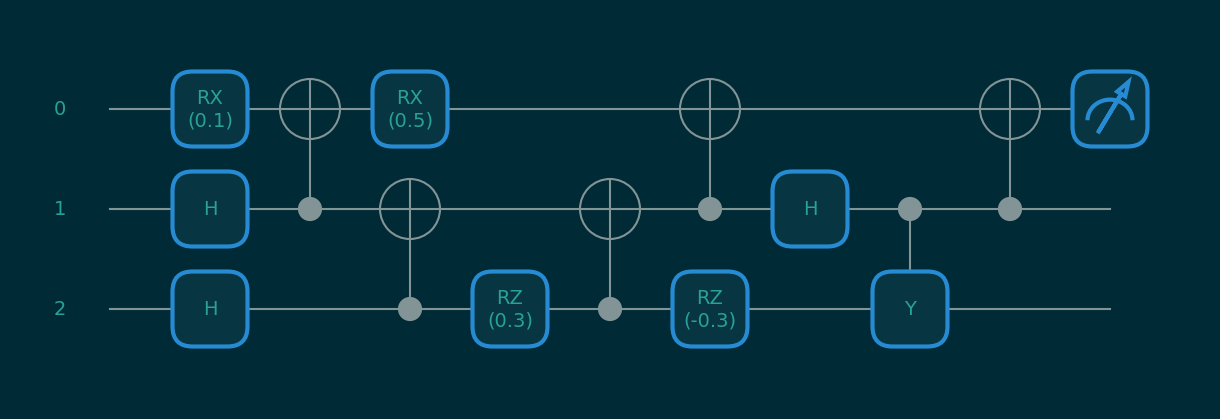

In [13]:
#Número de qubits
n_wires=3

#Creamos el device del circuito
dev = qml.device("default.qubit", wires=n_wires, shots=1)#Nombre, numero de qubits y shots

#Función que aplica puertas al circuito
def circuit(angles):
    #Puerta Hadamard
    qml.Hadamard(wires=1)#qubit 1
    qml.Hadamard(wires=2)#qubit 2
    #RX
    qml.RX(angles[0], 0)#Parámetro y qubit
    #CNOT
    qml.CNOT(wires=[1, 0])#Condicionante, condicionado
    qml.CNOT(wires=[2, 1])
    qml.RX(angles[2], wires=0)
    qml.RZ(angles[1], wires=2)
    qml.CNOT(wires=[2, 1])
    qml.RZ(-angles[1], wires=2)
    qml.CNOT(wires=[1, 0])
    qml.Hadamard(wires=1)
    qml.CY(wires=[1, 2])
    qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(wires=0))#Medimos el qubit 0

#Ángulos de entrada al circuito
angles = [0.1, 0.3, 0.5]

#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(circuit, dev)#Función de circuito y device, devuelve el circuito como función
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()


Hay una forma más compacta de hacerlo

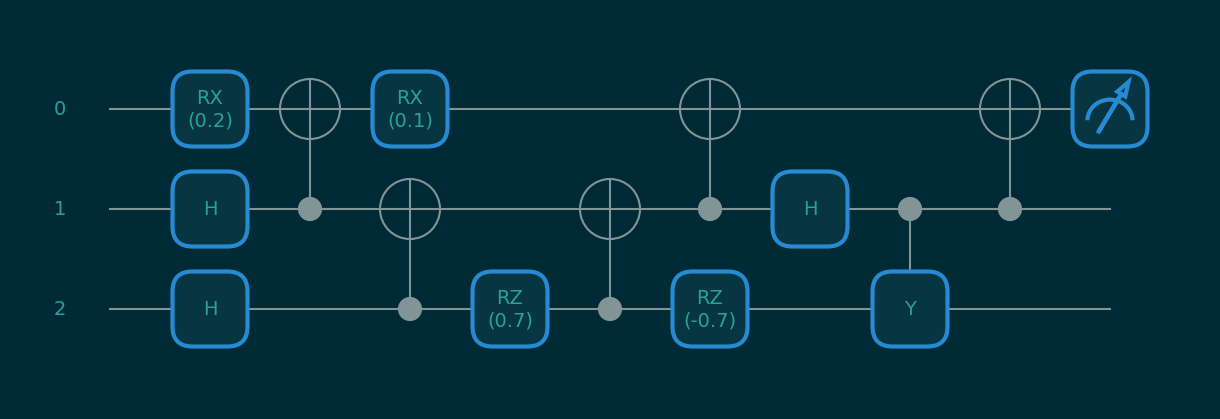

In [14]:
#Función que aplica puertas al circuito
@qml.qnode(dev)#Decorador con el device, igual a aplicar el QNode
def circuit(angles):
    #Puerta Hadamard
    qml.Hadamard(wires=1)#qubit 1
    qml.Hadamard(wires=2)#qubit 2
    #RX
    qml.RX(angles[0], 0)#Parámetro y qubit
    #CNOT
    qml.CNOT(wires=[1, 0])#Condicionante, condicionado
    qml.CNOT(wires=[2, 1])
    qml.RX(angles[2], wires=0)
    qml.RZ(angles[1], wires=2)
    qml.CNOT(wires=[2, 1])
    qml.RZ(-angles[1], wires=2)
    qml.CNOT(wires=[1, 0])
    qml.Hadamard(wires=1)
    qml.CY(wires=[1, 2])
    qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(wires=0))#Medimos el qubit 0

#Ángulos de entrada al circuito
angles = [0.2, 0.7, 0.1]

qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()


Podemos juntar las single-qubit gates

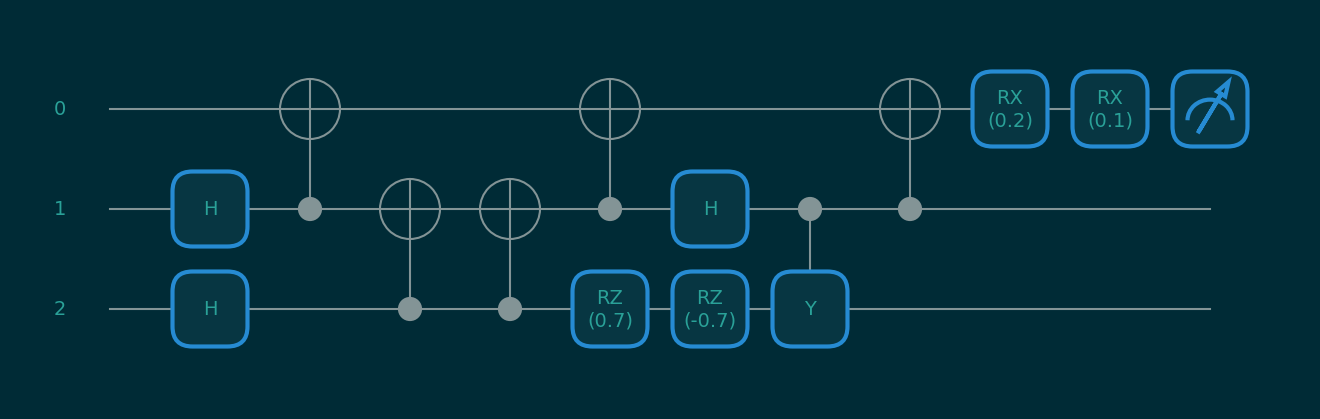

In [15]:
#Función que aplica puertas al circuito
#@qml.qnode(dev)#Decorador con el device, igual a aplicar el QNode
def circuit(angles):
    #Puerta Hadamard
    qml.Hadamard(wires=1)#qubit 1
    qml.Hadamard(wires=2)#qubit 2
    #RX
    qml.RX(angles[0], 0)#Parámetro y qubit
    #CNOT
    qml.CNOT(wires=[1, 0])#Condicionante, condicionado
    qml.CNOT(wires=[2, 1])
    qml.RX(angles[2], wires=0)
    qml.RZ(angles[1], wires=2)
    qml.CNOT(wires=[2, 1])
    qml.RZ(-angles[1], wires=2)
    qml.CNOT(wires=[1, 0])
    qml.Hadamard(wires=1)
    qml.CY(wires=[1, 2])
    qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(wires=0))#Medimos el qubit 0

#Ángulos de entrada al circuito
angles = [0.2, 0.7, 0.1]

#Juntamos lo máximo posible las single-qubit gates
commuted_circuit = qml.transforms.commute_controlled(direction="right")(circuit)
#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(commuted_circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()


Y puedes simplificar inversas

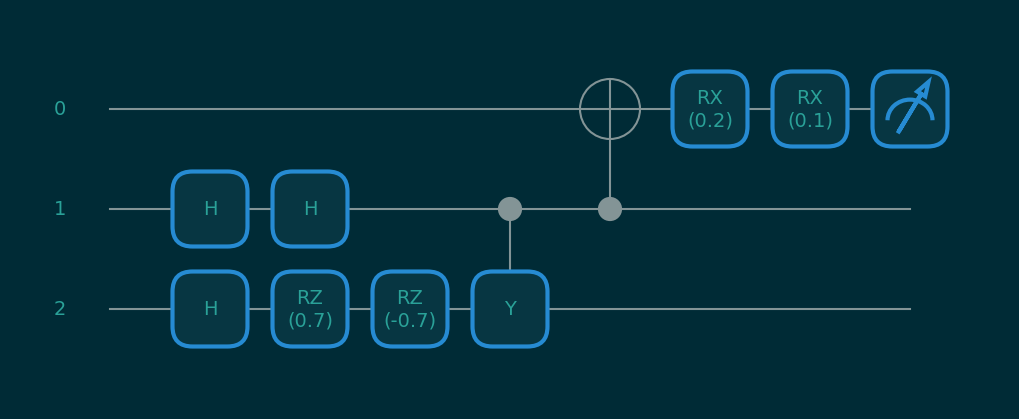

In [16]:
#Con esto simplificamos inversas entre ellas
cancelled_circuit = qml.transforms.cancel_inverses(commuted_circuit)

#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(cancelled_circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()

Podemos juntar las rotaciones en una sola puerta

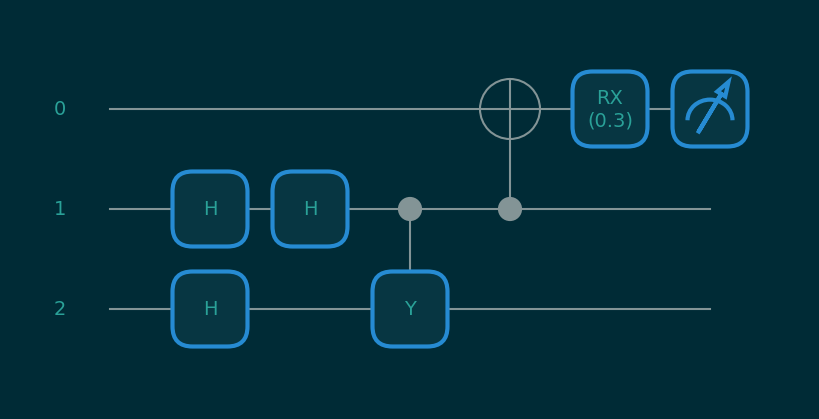

In [17]:
#Unimos las rotaciones, si el ángulo es menor que atol, se elimina la puerta
merged_circuit = qml.transforms.merge_rotations(atol=1e-8, include_gates=None)(cancelled_circuit)
#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(merged_circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()

Esto es muy pesado, por lo que lo hacemos de golpe. Lo hacemos por capas, cuanto más cerca al def, antes se aplica el decorador (de abajo a arriba)

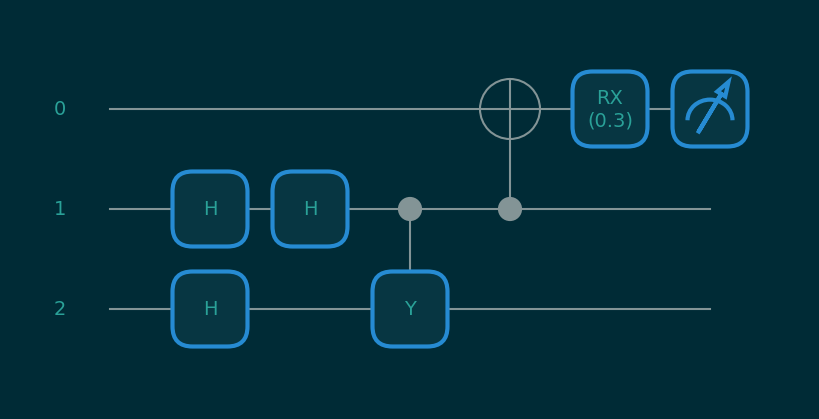

In [18]:
@qml.qnode(dev)#Aplicamos el QNode
@qml.transforms.merge_rotations(atol=1e-8, include_gates=None)#Unimos rotaciones
@qml.transforms.cancel_inverses#Cancelamos inversas
@qml.transforms.commute_controlled(direction="right")#Juntamos
def q_fun(angles):
    qml.Hadamard(wires=1)
    qml.Hadamard(wires=2)
    qml.RX(angles[0], 0)
    qml.CNOT(wires=[1, 0])
    qml.CNOT(wires=[2, 1])
    qml.RX(angles[2], wires=0)
    qml.RZ(angles[1], wires=2)
    qml.CNOT(wires=[2, 1])
    qml.RZ(-angles[1], wires=2)
    qml.CNOT(wires=[1, 0])
    qml.Hadamard(wires=1)
    qml.CY(wires=[1, 2])
    qml.CNOT(wires=[1, 0])
    return qml.expval(qml.PauliZ(wires=0))

#Ploteamos directamente
qml.draw_mpl(q_fun, decimals=1, style="solarized_dark")(angles)
plt.show()

# Compilación del circuito

Podemos hacerlo todo de golpe con una sola función

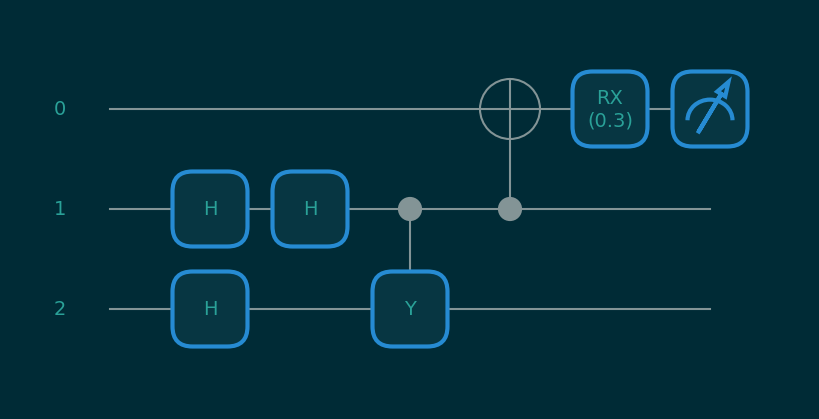

In [20]:
#Compilamos aplicando todo lo de antes
compiled_circuit = qml.compile(num_passes=1)(circuit)

#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(compiled_circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()

Pero vemos que aún hay cosas que podemos eliminar. Eso lo haremos aplicando el proceso de compilación varias veces

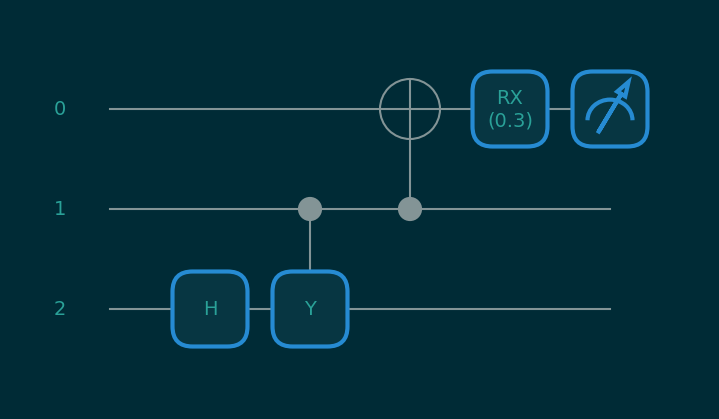

In [ ]:
#Compilamos aplicando todo lo de antes 2 veces, para borrar el doble Hadamard en el qubit 1
compiled_circuit = qml.compile(num_passes=2)(circuit)

#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(compiled_circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()

# Finito conjunto de puertas

Tenemos unas ciertas puertas en nuestro ordenador cuántico, así que queremos que el circuito se convierta en uno compatible

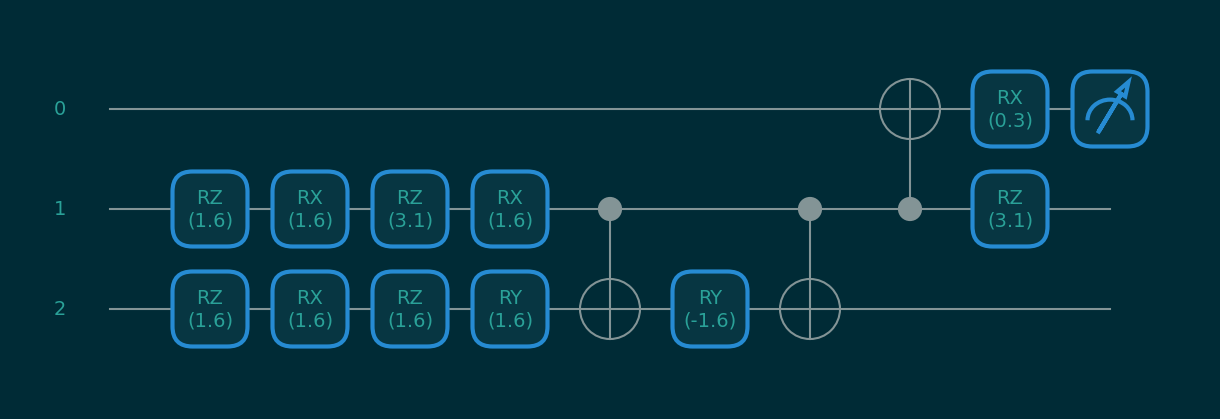

In [22]:
#Ponemos las puertas compatibles
compiled_circuit = qml.compile(basis_set=["CNOT", "RX", "RY", "RZ"], num_passes=2)(circuit)

#Aplicamos la función al circuito mediante QNode
qnode = qml.QNode(compiled_circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="solarized_dark")(angles)#Aplicamos los ángulos y ploteamos
plt.show()

# Embedding

Podemos poner un número directamente con el embedding. Lo ejemplificamos con este circuito que nos realiza una suma cuántica

In [23]:
n_wires = 4
dev = qml.device("default.qubit", wires=n_wires, shots=1)

def add_k_fourier(k, wires):
    for j in range(len(wires)):
        qml.RZ(k * np.pi / (2**j), wires=wires[j])

@qml.qnode(dev)
def sum(m, k):
    qml.BasisEmbedding(m, wires=range(n_wires)) # Codificamos el m en qubits (binario)

    qml.QFT(wires=range(n_wires)) # Aplicamos la QFT

    add_k_fourier(k, range(n_wires)) # Aplicamos la suma en Fourier

    qml.adjoint(qml.QFT)(wires=range(n_wires)) # Aplicamos la QFT inversa

    return qml.sample(wires=range(n_wires))#Con esto medimos, en los qubits que indicamos

print('Suma=', sum(3,4))

Suma= [[0 1 1 1]]


/home/mikel/QuantumComputing/QMLvenv/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Para más:

https://pennylane.ai/qml/demonstrations/getting-started